# LOADING DATA


In [1]:
!pip install geoviews cartopy holoviews jupyter_bokeh hvplot bokeh scikit-image global-land-mask --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import json
import warnings
import matplotlib.pyplot as plt
from skimage.graph import route_through_array
from global_land_mask import globe

warnings.filterwarnings('ignore')


In [3]:
from google.colab import drive
print("Mounting Google Drive...")
drive.mount('/content/drive')


Mounting Google Drive...
Mounted at /content/drive


In [4]:
file_path = "/content/drive/MyDrive/LCO2 Transport Project Final/cleaned_ais_copernicus_merged_dataset_2025.csv"
df = pd.read_csv(file_path)

REQUIRED_COLUMNS = {'LAT', 'LON', 'SOG', 'IMO'}
missing = REQUIRED_COLUMNS - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in the merged dataset: {missing}")

df.head()


,BaseDateTime,LON,LAT,SOG,COG,Heading,IMO,Status,Length,Width,Draft,Cargo,drift_angle,uo,vo,thetao,swh,mwd,wind_wave_height
0,2025-01-01 00:00:04,-90.29858,29.95597,14.3,40.7,41.0,IMO7816551,0.0,192.0,32.0,10.9,80.0,0.3,0.000000,0.000000,30.516485,0.00,0.000000,0.00
1,2025-01-01 00:00:03,-89.41682,29.35364,13.1,125.7,128.0,IMO9885908,0.0,229.0,35.0,13.9,80.0,2.3,0.000000,0.000000,11.113288,0.00,0.000000,0.00
2,2025-01-01 00:00:02,-95.20078,29.74000,4.6,52.9,54.0,IMO9724611,0.0,182.0,32.0,7.6,80.0,1.1,0.000000,0.000000,28.690380,0.00,0.000000,0.00
3,2025-01-01 00:00:07,-91.00400,30.16538,10.6,338.0,335.0,IMO9675078,0.0,147.0,23.0,8.4,81.0,-3.0,0.000000,0.000000,25.238691,0.00,0.000000,0.00
4,2025-01-01 00:00:04,-95.80819,27.19427,11.6,114.9,116.0,IMO9681857,0.0,183.0,32.0,8.2,80.0,1.1,-0.043143,-0.134023,24.470795,1.21,77.290002,0.84


# ROUTE WAYPOINTS


In [5]:
# CCS hub / terminal coordinates
HUBS = {
    'Bayou Bend':           (29.6000, -94.0000),
    'Houston Ship Channel': (29.3500, -94.7700),
    'Port Arthur':          (29.8930, -93.9380),
    'Plaquemine Corridor':  (30.2890, -91.2210),
    'ExxonMobil/Denbury':   (29.4610, -94.1970),
}

# Approximate river landmarks used to *anchor* the Plaquemine routes
MISSISSIPPI_RIVER_VIA = [
    (30.10,  -90.99),   # Donaldsonville, LA
    (29.95,  -90.07),   # New Orleans riverfront
    (29.277, -89.355),  # Venice, LA
    (29.157, -89.254),  # Head of Passes
    (28.95,  -89.12),   # South Pass mouth / clear of the delta
]

# Routes
ROUTES = {
    'GOM-HSC_BB':  {'origin': 'Houston Ship Channel', 'dest': 'Bayou Bend'},
    'GOM-HSC_EXM': {'origin': 'Houston Ship Channel', 'dest': 'ExxonMobil/Denbury'},
    'GOM-PAB_BB':  {'origin': 'Port Arthur', 'dest': 'Bayou Bend'},
    'GOM-PAB_EXM': {'origin': 'Port Arthur', 'dest': 'ExxonMobil/Denbury'},
    'GOM-PLQ_BB':  {'origin': 'Plaquemine Corridor', 'dest': 'Bayou Bend',
                     'via': MISSISSIPPI_RIVER_VIA, 'margin': 0.25, 'n_waypoints': 18},
    'GOM-PLQ_EXM': {'origin': 'Plaquemine Corridor', 'dest': 'ExxonMobil/Denbury',
                     'via': MISSISSIPPI_RIVER_VIA, 'margin': 0.25, 'n_waypoints': 18},
}

MIN_TRANSIT_SOG = 5.0
N_WAYPOINTS = 8            # default value overriden per-route with 'n_waypoints'
GRID_RES_DEG = 0.01        # ~1 km grid cells
DEFAULT_MARGIN_DEG = 0.4   # default search margin


In [6]:
df['is_transit'] = df['SOG'] >= MIN_TRANSIT_SOG

n_transit = int(df['is_transit'].sum())
print(f"Transit pings: {n_transit} / {len(df)} ({n_transit / len(df):.1%}) at SOG >= {MIN_TRANSIT_SOG}")


Transit pings: 333768 / 365318 (91.4%) at SOG >= 5.0


In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371.0088 * np.arcsin(np.sqrt(a))


def latlon_to_rc(lat, lon, lat_edges, lon_edges):
    row = int(np.clip(np.searchsorted(lat_edges, lat) - 1, 0, len(lat_edges) - 2))
    col = int(np.clip(np.searchsorted(lon_edges, lon) - 1, 0, len(lon_edges) - 2))
    return row, col


def land_or_sea(row, col, cost, threshold, max_radius=60):       # make sure no points on land
    if cost[row, col] < threshold:
        return row, col
    n_rows, n_cols = cost.shape
    for r in range(1, max_radius + 1):
        ring = [(row + dr, col + dc) for dr in range(-r, r + 1) for dc in range(-r, r + 1)
                if max(abs(dr), abs(dc)) == r]
        best = None
        for rr, cc in ring:
            if 0 <= rr < n_rows and 0 <= cc < n_cols and cost[rr, cc] < threshold:
                if best is None or cost[rr, cc] < cost[best]:
                    best = (rr, cc)
        if best is not None:
            return best


In [8]:
WATER_BASE, WATER_MIN = 1.0, 0.05
LAND_COST = 50.0
OPEN_WATER_COST = 3.0
LAND_THRESHOLD = (LAND_COST + OPEN_WATER_COST) / 2


def route_segment(transit_df, a, b, margin, res=GRID_RES_DEG):      # res is the physical size of the grids
    lat_min, lat_max = min(a[0], b[0]) - margin, max(a[0], b[0]) + margin
    lon_min, lon_max = min(a[1], b[1]) - margin, max(a[1], b[1]) + margin
    lat_edges = np.arange(lat_min, lat_max + res, res)
    lon_edges = np.arange(lon_min, lon_max + res, res)
    n_rows, n_cols = len(lat_edges) - 1, len(lon_edges) - 1

    sub = transit_df[
        transit_df['LAT'].between(lat_min, lat_max) & transit_df['LON'].between(lon_min, lon_max)
    ].copy()
    sub['row'] = np.clip(((sub['LAT'] - lat_min) / res).astype(int), 0, n_rows - 1)
    sub['col'] = np.clip(((sub['LON'] - lon_min) / res).astype(int), 0, n_cols - 1)

    # distinct vessels per cell, as one ship pinging multiple times can change density
    density = np.zeros((n_rows, n_cols))
    for (r, c), v in sub.groupby(['row', 'col'])['IMO'].nunique().items():
        density[r, c] = v

    lat_centers = lat_min + res * (np.arange(n_rows) + 0.5)
    lon_centers = lon_min + res * (np.arange(n_cols) + 0.5)
    lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
    land = globe.is_land(lat_grid, lon_grid)  # rom an external Python library -  global_land_mask - says if point is land or not - ues simplified digital model of the Earth's coastlines.

    log_density = np.log1p(density)
    dmax = log_density.max()
    density_norm = log_density / dmax if dmax > 0 else log_density
    cost = np.where(
        density > 0,
        WATER_BASE - (WATER_BASE - WATER_MIN) * density_norm,
        np.where(land, LAND_COST, OPEN_WATER_COST),
    )

    start = land_or_sea(*latlon_to_rc(*a, lat_edges, lon_edges), cost, LAND_THRESHOLD)
    end = land_or_sea(*latlon_to_rc(*b, lat_edges, lon_edges), cost, LAND_THRESHOLD)
    indices, _ = route_through_array(cost, start, end, fully_connected=True, geometric=True)  # function from scikit-image - Dijkstra algorithm. It connects the start node to the end node by finding the continuous string of adjacent grid cells with the lowest total travel cost
    indices = np.array(indices)
    ais_supported = float((density[indices[:, 0], indices[:, 1]] > 0).mean())

    path_lat = lat_edges[0] + res * (indices[:, 0] + 0.5)
    path_lon = lon_edges[0] + res * (indices[:, 1] + 0.5)
    path_lat = np.concatenate([[a[0]], path_lat, [b[0]]])
    path_lon = np.concatenate([[a[1]], path_lon, [b[1]]])

    return np.column_stack([path_lat, path_lon]), ais_supported


In [9]:
def resample_equidistant(path_latlon, n_points):
    lat, lon = path_latlon[:, 0], path_latlon[:, 1]
    step = haversine_km(lat[:-1], lon[:-1], lat[1:], lon[1:])
    cum = np.concatenate([[0], np.cumsum(step)])
    keep = np.concatenate([[True], cum[1:] > cum[:-1]])  # drop zero-length steps
    cum, lat, lon = cum[keep], lat[keep], lon[keep]
    target = np.linspace(0, cum[-1], n_points)
    return np.column_stack([np.interp(target, cum, lat), np.interp(target, cum, lon)])


In [10]:
def extract_route_waypoints(df: pd.DataFrame, plot: bool = True) -> dict:
    transit_df = df[df['is_transit']].copy()
    results = {}

    for route_name, spec in ROUTES.items():
        origin = HUBS[spec['origin']]
        dest = HUBS[spec['dest']]
        anchors = [origin] + spec.get('via', []) + [dest]
        margin = spec.get('margin', DEFAULT_MARGIN_DEG)
        n_wp = spec.get('n_waypoints', N_WAYPOINTS)

        via_note = f"  (via {len(spec.get('via', []))} anchor point(s))" if spec.get('via') else ""
        print(f"\n{route_name}: {spec['origin']} -> {spec['dest']}{via_note}")

        segments, supports = [], []
        for a, b in zip(anchors[:-1], anchors[1:]):
            seg_path, supp = route_segment(transit_df, a, b, margin)
            segments.append(seg_path)
            supports.append(supp)

        full_path = segments[0]
        for seg in segments[1:]:
            full_path = np.concatenate([full_path, seg[1:]], axis=0)  # drop repeated joint point

        waypoints_arr = resample_equidistant(full_path, n_wp)
        waypoints = [(round(float(lat), 4), round(float(lon), 4)) for lat, lon in waypoints_arr]

        path_km = float(haversine_km(full_path[:-1, 0], full_path[:-1, 1], full_path[1:, 0], full_path[1:, 1]).sum())
        overall_support = float(np.mean(supports))

        print(f"  path length: {path_km:.1f} km | AIS-supported: {overall_support:.0%}")
        if overall_support < 0.3:
            print("  \u26a0 low AIS support -- much of this route leans on the land-mask fallback, "
                  "not real ship traffic. Sanity-check it on the map below, and consider adding a "
                  "tighter 'via' anchor through the weak stretch.")
        for wp in waypoints:
            print(f"    {wp}")

        results[route_name] = {
            'description': f"{spec['origin']} \u2192 {spec['dest']}",
            'origin': [origin[0], origin[1]],
            'destination': [dest[0], dest[1]],
            'waypoints': waypoints,
            'path_length_km': round(path_km, 1),
            'ais_supported_fraction': round(overall_support, 3),
        }

        if plot:
            m = 0.15
            plat_min, plat_max = waypoints_arr[:, 0].min() - m, waypoints_arr[:, 0].max() + m
            plon_min, plon_max = waypoints_arr[:, 1].min() - m, waypoints_arr[:, 1].max() + m
            nearby = transit_df[
                transit_df['LAT'].between(plat_min, plat_max) & transit_df['LON'].between(plon_min, plon_max)
            ]
            sample = nearby.sample(n=min(len(nearby), 6000), random_state=42) if len(nearby) else nearby

            fig, ax = plt.subplots(figsize=(7, 6))
            if len(sample):
                ax.scatter(sample['LON'], sample['LAT'], s=3, c='lightgray', label='transit AIS pings')
            ax.plot(waypoints_arr[:, 1], waypoints_arr[:, 0], '-o', c='crimson',
                    linewidth=2, markersize=5, label='route waypoints')
            ax.scatter([origin[1], dest[1]], [origin[0], dest[0]], s=90, c='black', marker='*',
                       zorder=5, label='origin/destination')
            ax.set_title(f"{route_name}  ({path_km:.0f} km, {overall_support:.0%} AIS-supported)")
            ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()

    return results


## 3. Save outputs


In [11]:
def assemble_and_output(waypoints: dict) -> None:
    wp_path = '/content/drive/MyDrive/LCO2 Transport Project Final/route_waypoints.json'
    with open(wp_path, 'w') as f:
        json.dump(waypoints, f, indent=2)
    print(f"\u2713 Written: {wp_path}")


## Run



GOM-HSC_BB: Houston Ship Channel -> Bayou Bend
  path length: 118.3 km | AIS-supported: 88%
    (29.35, -94.77)
    (29.3078, -94.6278)
    (29.2327, -94.4927)
    (29.165, -94.3539)
    (29.2605, -94.2295)
    (29.3553, -94.1047)
    (29.4633, -93.9867)
    (29.6, -94.0)


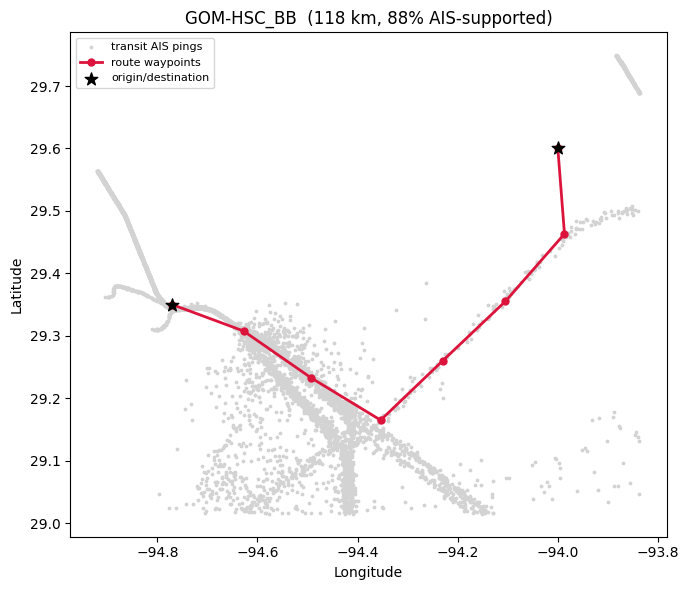


GOM-HSC_EXM: Houston Ship Channel -> ExxonMobil/Denbury
  path length: 97.8 km | AIS-supported: 88%
    (29.35, -94.77)
    (29.321, -94.651)
    (29.2593, -94.5393)
    (29.1844, -94.4344)
    (29.1942, -94.3158)
    (29.2757, -94.2143)
    (29.3666, -94.125)
    (29.461, -94.197)


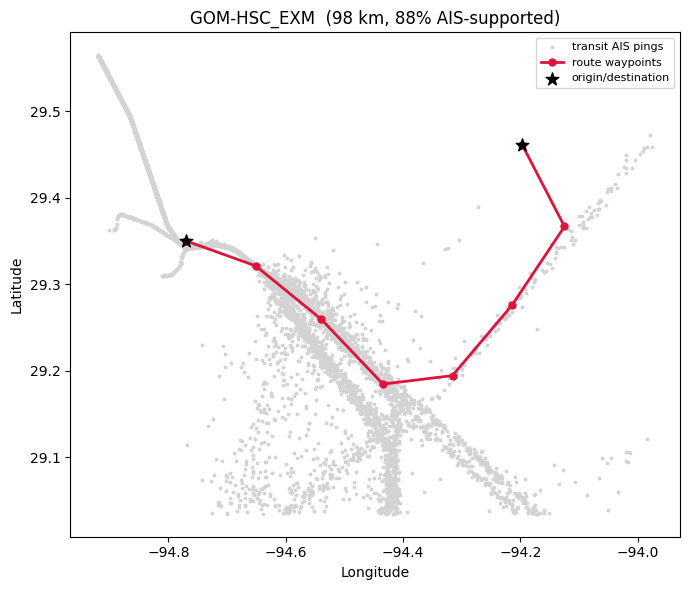


GOM-PAB_BB: Port Arthur -> Bayou Bend
  path length: 81.4 km | AIS-supported: 85%
    (29.893, -93.938)
    (29.804, -93.955)
    (29.7359, -93.8759)
    (29.6479, -93.825)
    (29.5634, -93.7634)
    (29.505, -93.8299)
    (29.5211, -93.9311)
    (29.6, -94.0)


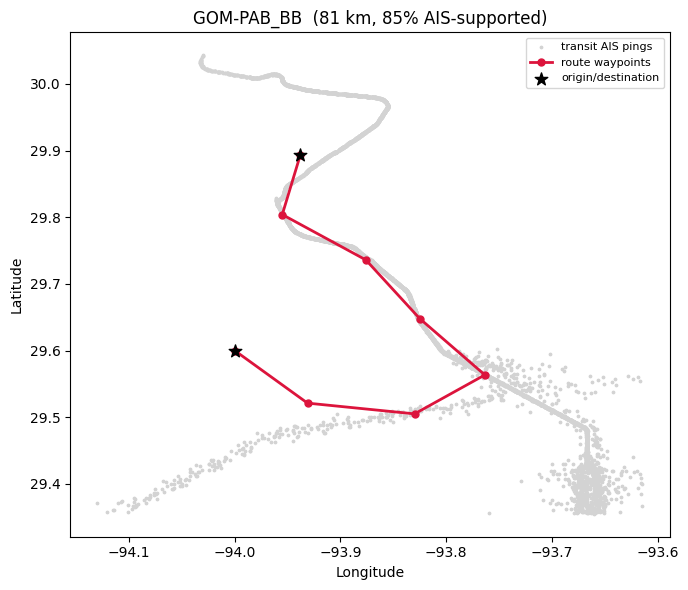


GOM-PAB_EXM: Port Arthur -> ExxonMobil/Denbury
  path length: 108.5 km | AIS-supported: 90%
    (29.893, -93.938)
    (29.7799, -93.9359)
    (29.685, -93.832)
    (29.5719, -93.7679)
    (29.5036, -93.8544)
    (29.4575, -93.9905)
    (29.366, -94.1028)
    (29.461, -94.197)


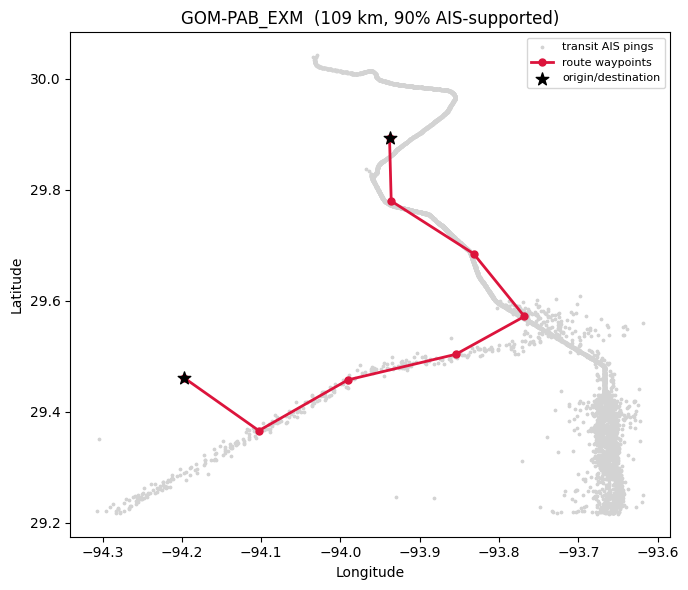


GOM-PLQ_BB: Plaquemine Corridor -> Bayou Bend  (via 5 anchor point(s))
  path length: 1048.0 km | AIS-supported: 88%
    (30.289, -91.221)
    (30.115, -91.0005)
    (30.0504, -90.5604)
    (29.92, -90.13)
    (29.7422, -90.0152)
    (29.4149, -89.605)
    (29.1082, -89.269)
    (28.7993, -89.2633)
    (28.765, -89.3248)
    (28.795, -89.8218)
    (28.765, -90.3768)
    (28.725, -90.9884)
    (28.715, -91.6154)
    (28.715, -92.2475)
    (28.715, -92.8797)
    (28.8495, -93.4195)
    (29.3262, -93.6562)
    (29.6, -94.0)


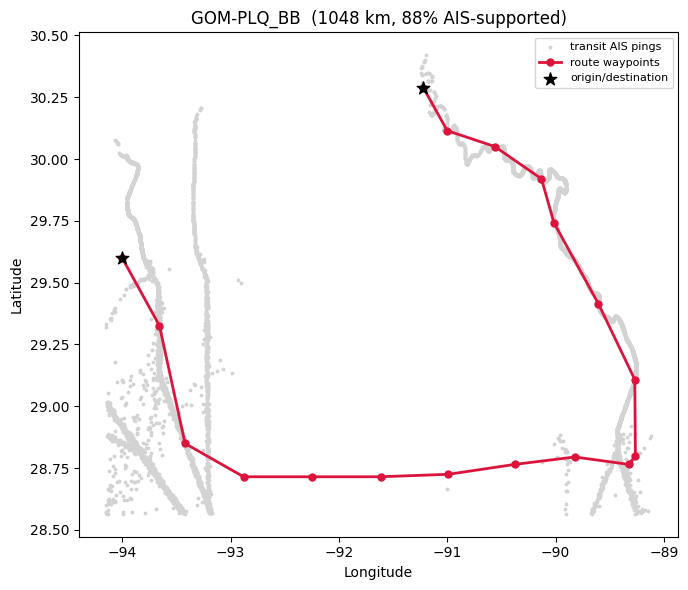


GOM-PLQ_EXM: Plaquemine Corridor -> ExxonMobil/Denbury  (via 5 anchor point(s))
  path length: 1075.7 km | AIS-supported: 88%
    (30.289, -91.221)
    (30.115, -90.9836)
    (30.045, -90.5294)
    (29.915, -90.0924)
    (29.702, -89.975)
    (29.3695, -89.5525)
    (29.0386, -89.3254)
    (28.8482, -89.1758)
    (28.8039, -89.4531)
    (28.845, -89.9519)
    (28.765, -90.5495)
    (28.715, -91.1726)
    (28.715, -91.8215)
    (28.715, -92.4703)
    (28.715, -93.1192)
    (29.0256, -93.5726)
    (29.5267, -93.7237)
    (29.461, -94.197)


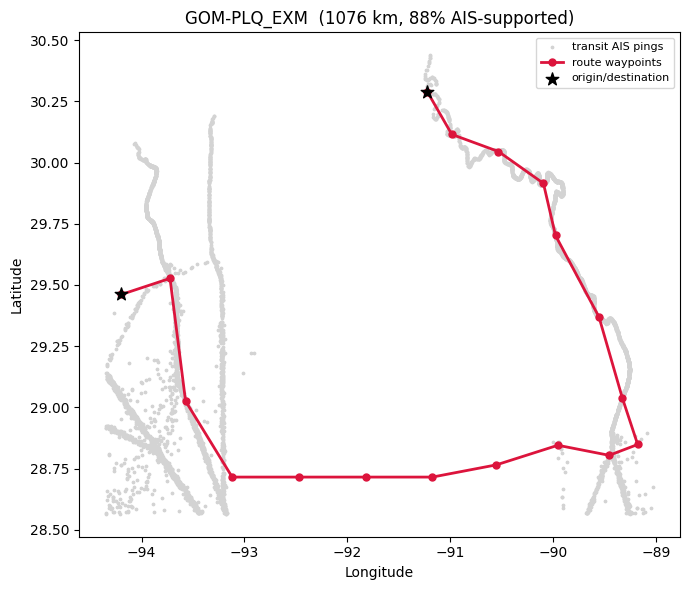

✓ Written: /content/drive/MyDrive/LCO2 Transport Project Final/route_waypoints.json

ROUTE WAYPOINTS 

GOM-HSC_BB  (118.3 km, 88% AIS-supported):
    (29.3500, -94.7700)
    (29.3078, -94.6278)
    (29.2327, -94.4927)
    (29.1650, -94.3539)
    (29.2605, -94.2295)
    (29.3553, -94.1047)
    (29.4633, -93.9867)
    (29.6000, -94.0000)

GOM-HSC_EXM  (97.8 km, 88% AIS-supported):
    (29.3500, -94.7700)
    (29.3210, -94.6510)
    (29.2593, -94.5393)
    (29.1844, -94.4344)
    (29.1942, -94.3158)
    (29.2757, -94.2143)
    (29.3666, -94.1250)
    (29.4610, -94.1970)

GOM-PAB_BB  (81.4 km, 86% AIS-supported):
    (29.8930, -93.9380)
    (29.8040, -93.9550)
    (29.7359, -93.8759)
    (29.6479, -93.8250)
    (29.5634, -93.7634)
    (29.5050, -93.8299)
    (29.5211, -93.9311)
    (29.6000, -94.0000)

GOM-PAB_EXM  (108.5 km, 90% AIS-supported):
    (29.8930, -93.9380)
    (29.7799, -93.9359)
    (29.6850, -93.8320)
    (29.5719, -93.7679)
    (29.5036, -93.8544)
    (29.4575, -93.9905)
  

In [12]:
waypoints = extract_route_waypoints(df)
assemble_and_output(waypoints)

print("\nROUTE WAYPOINTS ")
for route, data in waypoints.items():
    print(f"\n{route}  ({data['path_length_km']} km, {data['ais_supported_fraction']:.0%} AIS-supported):")
    for i, (lat, lon) in enumerate(data['waypoints'], start=1):
        print(f"    ({lat:.4f}, {lon:.4f})")


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
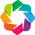

:HoloMap   [Route]
   :Overlay
      .WMTS.I           :WMTS   [Longitude,Latitude]
      .Path.Route       :Path   [Longitude,Latitude]
      .Points.Waypoints :Points   [lon,lat]   (order)
      .Points.CCS_Hubs  :Points   [lon,lat]   (name)
      .Labels.I         :Labels   [lon,lat]   (name)

In [13]:
import holoviews as hv
import geoviews as gv
from holoviews import opts
from cartopy import crs

hv.extension('bokeh')

# CCS hub / terminal locations referenced by the route corridors above
hub_data = pd.DataFrame([
    {'name': 'Bayou Bend',              'lat': 29.6000, 'lon': -94.0000},
    {'name': 'Houston Ship Channel',    'lat': 29.3500, 'lon': -94.7700},
    {'name': 'Port Arthur',             'lat': 29.8930, 'lon': -93.9380},
    {'name': 'Plaquemine Corridor',     'lat': 30.2890, 'lon': -91.2210},
    {'name': 'ExxonMobil / Denbury Lease', 'lat': 29.4610, 'lon': -94.1970},
])

hub_points = gv.Points(hub_data, kdims=['lon', 'lat'], label='CCS Hubs').opts(
    size=12, color='red', marker='triangle', line_color='black', tools=['hover']
)

hub_labels = gv.Labels(hub_data, kdims=['lon', 'lat'], vdims='name').opts(
    text_font_size='9pt', text_color='red', text_font_style='bold', xoffset=0.15
)


def plot_route_waypoints(route_name: str):
    #Build a basemap + waypoint path + waypoint markers overlay for one route.
    route = waypoints[route_name]
    wps = route['waypoints']

    path_coords = [(lon, lat) for lat, lon in wps]
    route_path = gv.Path([path_coords], crs=crs.PlateCarree(), label='Route').opts(
        color='crimson', line_width=3
    )

    wp_df = pd.DataFrame(wps, columns=['lat', 'lon'])
    wp_df['order'] = range(1, len(wp_df) + 1)
    route_points = gv.Points(wp_df, kdims=['lon', 'lat'], vdims=['order'], label='Waypoints').opts(
        size=9, color='crimson', line_color='black', tools=['hover']
    )

    basemap = gv.tile_sources.OSM

    return (basemap * route_path * route_points * hub_points * hub_labels).opts(
        opts.Overlay(width=900, height=650, title=f"{route_name}: {route['description']}")
    )


# dropdown
route_names = list(waypoints.keys())
interactive_routes = hv.HoloMap(
    {route: plot_route_waypoints(route) for route in route_names},
    kdims='Route'
)

interactive_routes


## AIS density vs. calculated route

Same one-route-at-a-time selector as above, but with the underlying
transit AIS ping density drawn as a heatmap instead of a plain basemap.
Use it to check that the cyan waypoints actually track through real
traffic density rather than drifting into a stretch with little or no
AIS support -- this is especially worth checking on the Plaquemine/PBR
routes, where `ais_supported_fraction` already flags this numerically
but seeing it on the map makes it obvious exactly *where* the weak
stretch is.


In [14]:
def route_density_grid(route_name: str, bin_deg: float = 0.02, margin: float = 0.5):
    route = waypoints[route_name]
    wp = np.array(route['waypoints'])

    lat_min, lat_max = wp[:, 0].min() - margin, wp[:, 0].max() + margin
    lon_min, lon_max = wp[:, 1].min() - margin, wp[:, 1].max() + margin

    nearby = df[
        df['is_transit'] & df['LAT'].between(lat_min, lat_max) & df['LON'].between(lon_min, lon_max)
    ]

    lat_edges = np.arange(lat_min, lat_max + bin_deg, bin_deg)
    lon_edges = np.arange(lon_min, lon_max + bin_deg, bin_deg)
    counts, _, _ = np.histogram2d(nearby['LAT'], nearby['LON'], bins=[lat_edges, lon_edges])
    counts[counts == 0] = np.nan  # transparent where there's no traffic at all

    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    return lon_centers, lat_centers, counts, len(nearby)


def plot_route_density(route_name: str):
    route = waypoints[route_name]
    lon_centers, lat_centers, counts, n_pings = route_density_grid(route_name)

    density_img = gv.Image(
        (lon_centers, lat_centers, counts), kdims=['lon', 'lat'], vdims='pings', crs=crs.PlateCarree()
    ).opts(cmap='inferno', colorbar=True, logz=True, alpha=0.85, tools=['hover'], clabel='transit AIS pings')

    path_coords = [(lon, lat) for lat, lon in route['waypoints']]
    route_path = gv.Path([path_coords], crs=crs.PlateCarree(), label='Route').opts(
        color='cyan', line_width=3
    )

    wp_df = pd.DataFrame(route['waypoints'], columns=['lat', 'lon'])
    wp_df['order'] = range(1, len(wp_df) + 1)
    route_points = gv.Points(wp_df, kdims=['lon', 'lat'], vdims=['order'], label='Waypoints').opts(
        size=9, color='cyan', line_color='black', tools=['hover']
    )

    basemap = gv.tile_sources.OSM

    return (basemap * density_img * route_path * route_points * hub_points * hub_labels).opts(
        opts.Overlay(
            width=900, height=650,
            title=f"{route_name}: AIS ping density and calculated route  ({n_pings:,} pings shown)",
        )
    )


density_maps = hv.HoloMap(
    {route: plot_route_density(route) for route in route_names},
    kdims='Route'
)

density_maps


:HoloMap   [Route]
   :Overlay
      .WMTS.I           :WMTS   [Longitude,Latitude]
      .Image.I          :Image   [lon,lat]   (pings)
      .Path.Route       :Path   [Longitude,Latitude]
      .Points.Waypoints :Points   [lon,lat]   (order)
      .Points.CCS_Hubs  :Points   [lon,lat]   (name)
      .Labels.I         :Labels   [lon,lat]   (name)